In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import mygene
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from numpy import absolute
from sklearn.impute import SimpleImputer
import shap
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm
from lightgbm import LGBMRegressor, early_stopping
import catboost as cb
from catboost import CatBoostRegressor
from sklearn.metrics import accuracy_score

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_theme(
    style="ticks",
    rc={"axes.spines.top": False, "axes.spines.right": False}
)
sns.set_context('paper')  # or 'talk', 'notebook', 'poster'
custom_palette = [
    "#b3cde3",  # pastel blue (like Peakachu)
    "#8da0cb",  # mid blue (like Mustache)
    "#a6bddb",  # muted blue
    "#bebada",  # blue-lavender
    "#7b8ed9",  # strong blue
    "#5e6ec8",  # deep blue-purple (like Cooltools)
]
sns.set_palette(custom_palette)

In [3]:
merged = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/loop_geneexp_integration.tsv", sep="\t")
merged

,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol,gene_log2fc
0,0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,...,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,388591,RNF207,-0.733
1,1,29,chr1,9782500,9787500,chr1,9862500,9867500,shared,0.049133,...,0.0632,0.674870,0.842693,0.835179,0.690057,0.167823,-0.145121,22883,CLSTN1,0.624
2,2,71,chr1,21222500,21227500,chr1,21572500,21577500,shared,0.015427,...,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,1889,ECE1,0.743
3,3,77,chr1,22665000,22670000,chr1,22960000,22965000,shared,0.025278,...,0.0320,0.587471,0.558545,0.492335,0.536689,-0.028926,0.044354,2048,EPHB2,0.881
4,4,78,chr1,22672500,22677500,chr1,22882500,22887500,shared,0.019734,...,0.0034,0.587471,0.558545,0.661385,0.647487,-0.028926,-0.013898,2048,EPHB2,0.881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160,1160,32165,chr7,51412500,51417500,chr7,55602500,55607500,gained,0.021059,...,0.0042,0.406646,0.454487,0.610640,0.678323,0.047841,0.067683,1956,EGFR,0.761
1161,1161,32208,chr8,94812500,94817500,chr8,95022500,95027500,gained,0.012306,...,0.0298,0.040931,0.090414,0.528279,0.409177,0.049483,-0.119102,9134,CCNE2,-0.729
1162,1162,32213,chr8,122735000,122740000,chr8,123060000,123065000,gained,0.005878,...,0.0084,0.580906,0.531595,-0.156556,-0.213083,-0.049312,-0.056527,22882,ZHX2,0.754
1163,1163,32230,chr9,33582500,33587500,chr9,38552500,38557500,gained,0.040927,...,0.0044,-0.120256,-0.077855,0.011444,-0.040473,0.042401,-0.051918,7169,TPM2,-1.545


In [4]:
merged.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'chr1', 'start1', 'end1', 'chr2',
       'start2', 'end2', 'status', 'ctrl_signal', 'rbp1_signal', 'log2FC',
       'log2FC_clipped', 'condition', 'distance', 'loop_id', 'comp_switch_A1',
       'comp_switch_A2', 'loop_class', 'source', 'CTCF_signal',
       'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal', 'GC_mean',
       'GC_diff', 'E1_anchor1_ctrl', 'E1_anchor1_rbp1', 'E1_anchor2_ctrl',
       'E1_anchor2_rbp1', 'delta_E1_anchor1', 'delta_E1_anchor2', 'gene_id',
       'gene_symbol', 'gene_log2fc'],
      dtype='object')

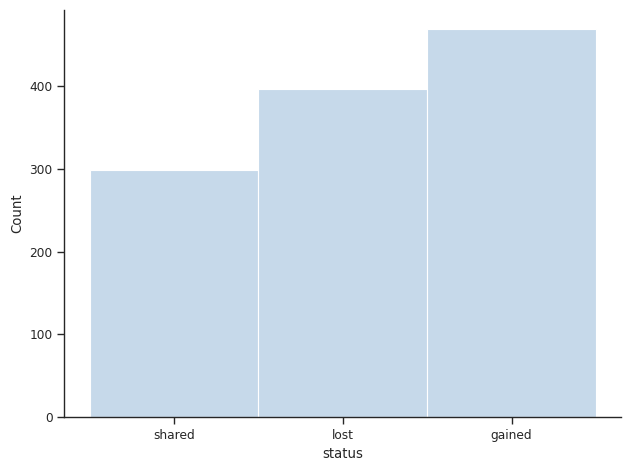

In [5]:
ax = sns.histplot(
    data=merged,
    x="status", 
)
plt.tight_layout()
plt.show()

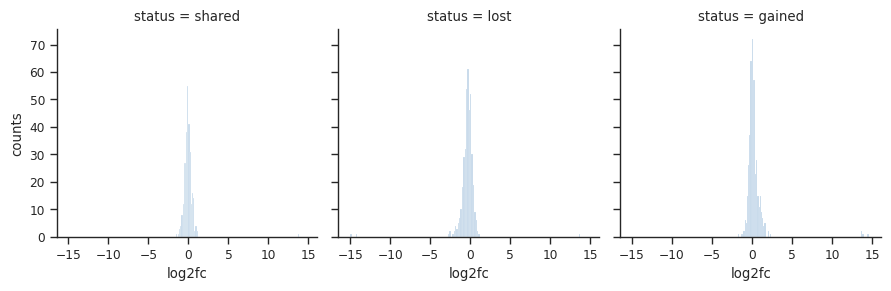

In [6]:
# FacetGrid for multi-category subplots

g = sns.FacetGrid(merged, col="status")
g.map_dataframe(
    sns.histplot,
    x="log2FC"
)
g.set_axis_labels("log2fc", "counts")
plt.tight_layout()
plt.show()

In [7]:
merged[merged["status"] == "shared"]

,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,gene_id,gene_symbol,gene_log2fc
0,0,8,chr1,6105000,6110000,chr1,6240000,6245000,shared,NaN,...,0.0164,NaN,0.829346,NaN,NaN,NaN,NaN,388591,RNF207,-0.733
1,1,29,chr1,9782500,9787500,chr1,9862500,9867500,shared,0.049133,...,0.0632,0.674870,0.842693,0.835179,0.690057,0.167823,-0.145121,22883,CLSTN1,0.624
2,2,71,chr1,21222500,21227500,chr1,21572500,21577500,shared,0.015427,...,0.0348,0.463574,0.456581,0.598057,0.652091,-0.006993,0.054035,1889,ECE1,0.743
3,3,77,chr1,22665000,22670000,chr1,22960000,22965000,shared,0.025278,...,0.0320,0.587471,0.558545,0.492335,0.536689,-0.028926,0.044354,2048,EPHB2,0.881
4,4,78,chr1,22672500,22677500,chr1,22882500,22887500,shared,0.019734,...,0.0034,0.587471,0.558545,0.661385,0.647487,-0.028926,-0.013898,2048,EPHB2,0.881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,294,7360,chrX,37742500,37747500,chrX,38172500,38177500,shared,0.012702,...,0.0186,1.073586,1.025712,0.865611,0.950734,-0.047874,0.085123,8406,SRPX,0.846
295,295,7377,chrX,51622500,51627500,chrX,52242500,52247500,shared,0.005325,...,0.0400,0.814139,0.637226,0.938958,0.917371,-0.176914,-0.021587,9500,MAGED1,0.691
296,296,7400,chrX,74380000,74385000,chrX,74455000,74460000,shared,0.036933,...,0.0028,0.894791,0.810972,0.924790,0.834357,-0.083820,-0.090433,6567,SLC16A2,0.749
297,297,7401,chrX,74385000,74390000,chrX,74540000,74545000,shared,0.016460,...,0.0562,0.924790,0.834357,0.619460,0.637803,-0.090433,0.018342,6567,SLC16A2,0.749


R² = 0.0113
Coefficients:
  log2FC: -0.0151
  H3K27me3_signal: 0.0113
  CTCF_signal: 0.0042
  rad21_signal: -2.9203
  delta_E1_anchor1: -0.0599
  delta_E1_anchor2: 0.2100
  loopclass_gained: 0.0444
  loopclass_lost: -0.0401
  loopclass_shared: -0.0043
Intercept: 0.5909


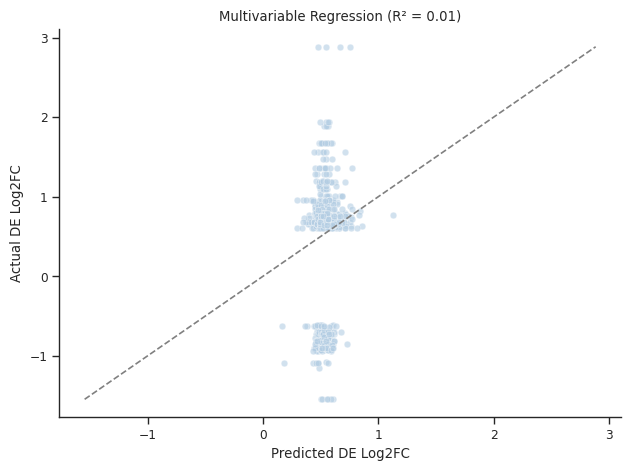

In [8]:
### multivariate

# Step 1: Select relevant features
feature_cols = [
    "log2FC",     # transformed contact frequency
    "H3K27me3_signal",
    "CTCF_signal",
    "rad21_signal",
    "delta_E1_anchor1",
    "delta_E1_anchor2",
    "status"  # categorical (shared/gained/lost)
]

target_col = "gene_log2fc"  # DE expression

# Step 2: Drop rows with missing values in selected columns
df = merged[feature_cols + [target_col]].dropna()

# Step 3: One-hot encode 'status'
status_encoded = pd.get_dummies(df["status"], prefix="loopclass")
df = pd.concat([df.drop(columns="status"), status_encoded], axis=1)

# Step 4: Define X and y
X = df.drop(columns=target_col)
y = df[target_col]

# Step 5: Fit linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Step 6: Evaluate
r2 = r2_score(y, y_pred)
print(f"R² = {r2:.4f}")
print("Coefficients:")
for name, coef in zip(X.columns, model.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# Step 7: Plot predicted vs actual
sns.scatterplot(x=y_pred, y=y, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='gray')
plt.xlabel("Predicted DE Log2FC")
plt.ylabel("Actual DE Log2FC")
plt.title(f"Multivariable Regression (R² = {r2:.2f})")
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:            gene_log2fc   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7155
Date:                Fri, 22 Aug 2025   Prob (F-statistic):              0.398
Time:                        12:38:15   Log-Likelihood:                -1078.1
No. Observations:                1122   AIC:                             2160.
Df Residuals:                    1120   BIC:                             2170.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5345      0.019     28.281      0.0

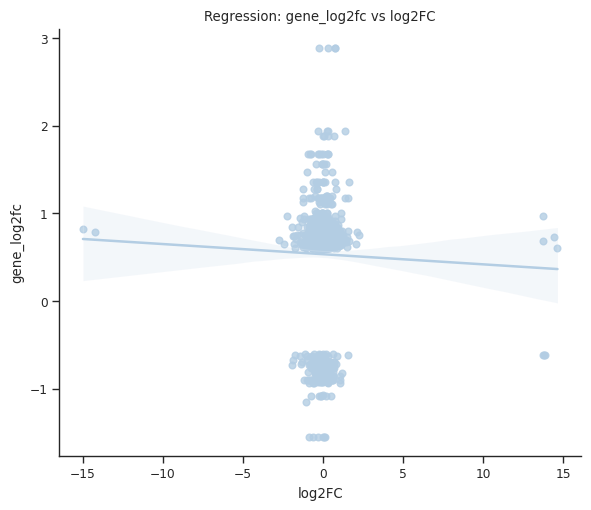

In [9]:
import statsmodels.api as sm

# Drop NaN values for clean regression
df = merged[['gene_log2fc', 'log2FC']].dropna()

# Define variables
X = df['log2FC']
y = df['gene_log2fc']

# Add constant for intercept
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()

# Print regression summary
print(model.summary())

# Plot scatter + regression line
sns.lmplot(data=df, x='log2FC', y='gene_log2fc', aspect=1.2, height=5)
plt.title("Regression: gene_log2fc vs log2FC")
plt.show()

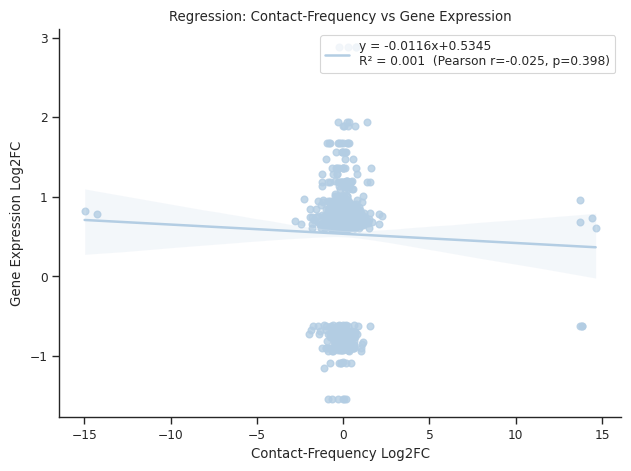

In [10]:
from scipy.stats import pearsonr

# --- clean data ---
df = (merged[['log2FC', 'gene_log2fc']]
      .replace([np.inf, -np.inf], np.nan)
      .dropna())

X = df[['log2FC']].values          # 2D
y = df['gene_log2fc'].values       # 1D

# --- fit ---
model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_

# optional correlation
r, p = pearsonr(df['log2FC'], df['gene_log2fc'])

# --- plot ---
ax = sns.regplot(
    data=df, x='log2FC', y='gene_log2fc',
    line_kws={"label": f"y = {slope:.4f}x{intercept:+.4f}\nR² = {r2:.3f}  (Pearson r={r:.3f}, p={p:.3g})"}
)
ax.set_xlabel("Contact-Frequency Log2FC")
ax.set_ylabel("Gene Expression Log2FC")
ax.set_title("Regression: Contact-Frequency vs Gene Expression")
ax.legend()
plt.tight_layout()
plt.show()


---

### grad. boost

---

In [11]:
## xgboost

Test MAE: 0.336 | RMSE: 0.528 | R²: -0.347
CV R²: -0.109 (0.207)


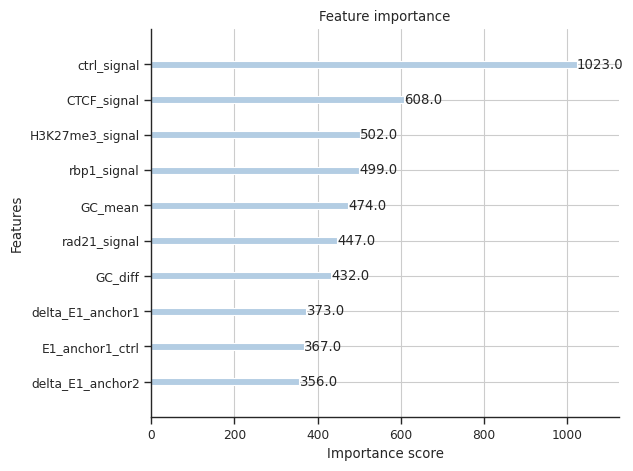

R² on test set: -0.3466


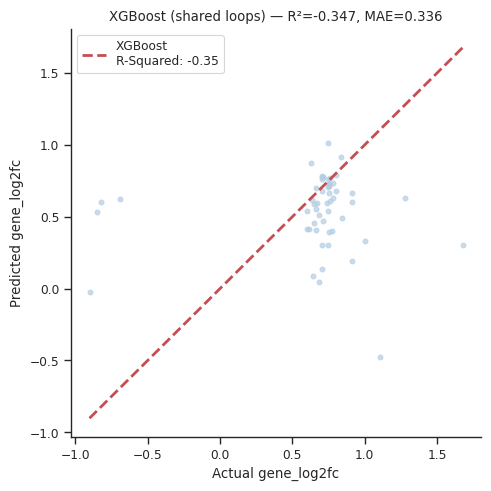

In [12]:
LOW, HIGH = -5, 5

# subset
df = merged[merged['status'] == 'shared'].copy()

feat_cols = [
    'ctrl_signal','rbp1_signal',
    'CTCF_signal','H3K27me3_signal','H3K4me3_signal','rad21_signal',
    'GC_mean','GC_diff',
    'E1_anchor1_ctrl','E1_anchor1_rbp1','E1_anchor2_ctrl','E1_anchor2_rbp1',
    'delta_E1_anchor1','delta_E1_anchor2','log2FC'
]
if 'distance' in df.columns:
    df['log_distance'] = np.log1p(df['distance'])
    feat_cols.append('log_distance') # taking log of the distance
    ## These are the features fed to the model

# build feature frame
X = df[feat_cols].copy()

# one‑hot encode loop_class ## categorical
if 'loop_class' in df.columns:
    X = pd.concat([X, pd.get_dummies(df['loop_class'], prefix='loop_class', dummy_na=True)], axis=1)

# target
y = df['gene_log2fc'].copy() # target is the Differential expression log fold change

# outlier trim on both target and log2FC predictor ## Usually outliers are problematic
mask = y.between(LOW, HIGH) & X['log2FC'].between(LOW, HIGH)
X = X.loc[mask]
y = y.loc[mask]

# clean NaNs/Infs and keep aligned indices ## xgboost doesn't handle NaNs
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]  # align

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model
model = XGBRegressor(
    n_estimators=1000, max_depth=7, eta=0.1,
    subsample=0.7, colsample_bytree=0.8,
    reg_lambda=1.0, random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

# metrics
y_pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # MAE
r2   = r2_score(y_test, y_pred)
print(f"Test MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f}") # Test R2

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
cv_r2  = cross_val_score(model, X, y, scoring='r2', cv=cv, n_jobs=-1)
print(f"CV R²: {cv_r2.mean():.3f} ({cv_r2.std():.3f})") # Cross val. R2
from xgboost import plot_importance
plot_importance(model, max_num_features=10)
plt.tight_layout()
plt.show()
# Fit model
model.fit(X_train, y_train)

# Predict and evaluate R²
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R² on test set: {r2:.4f}")
# === plot: actual vs predicted ===
r_squared = f"R-Squared: {r2:.2f}"
model_info = f"XGBoost\n{r_squared}"

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, s=12, alpha=0.7)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--', lw=2, label=model_info)
plt.xlabel("Actual gene_log2fc")
plt.ylabel("Predicted gene_log2fc")
plt.title(f"XGBoost (shared loops) — R²={r2:.3f}, MAE={mae:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

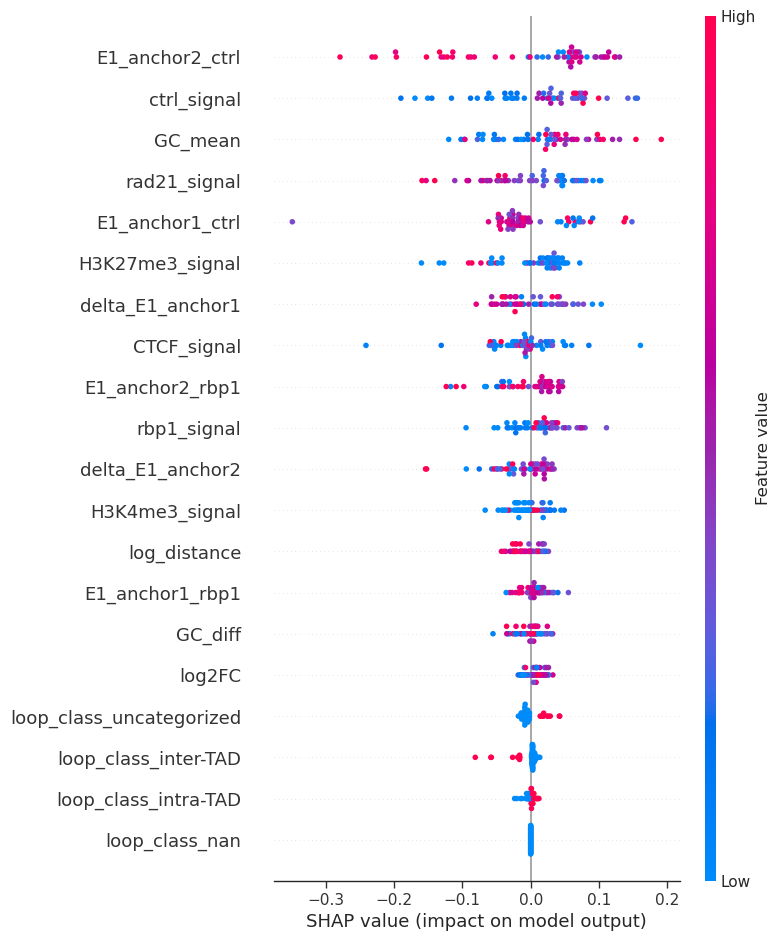

In [13]:
# model explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

In [14]:
# LightGBM

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1078
[LightGBM] [Info] Number of data points in the train set: 212, number of used features: 19
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Info] Start training from score 0.514708
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

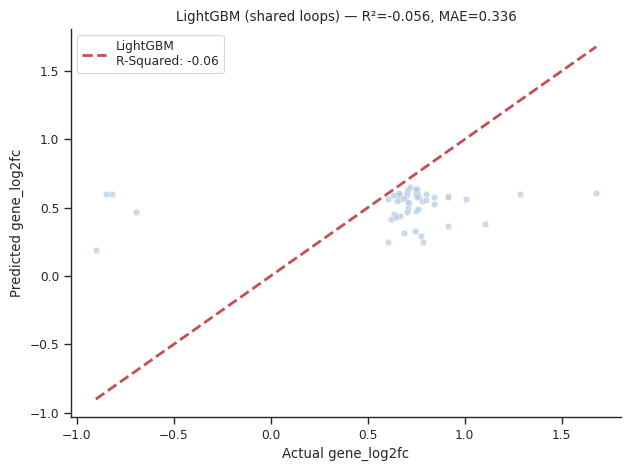

In [15]:
# Reuse X_train, X_test, y_train, y_test from the XGB cell

lgbm = LGBMRegressor(
    objective='regression',
    metric='rmse',
    boosting_type='gbdt',
    num_leaves=31,
    learning_rate=0.05,
    feature_fraction=0.9,
    n_estimators=2000,      # plenty of rounds; early_stopping will cut it
    random_state=42,
    n_jobs=-1
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_names=['valid'],
    callbacks=[early_stopping(stopping_rounds=100, verbose=False)]
)

# Predictions + metrics
y_pred = lgbm.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"Test RMSE: {rmse:.3f} | Test R²: {r2:.3f}")

# Feature importance (gain)
imp = pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop features:\n", imp.head(15))

# Actual vs Predicted plot
r_squared = f"R-Squared: {r2:.2f}"
model_info = f"LightGBM\n{r_squared}"

ax = sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
mn = min(y_test.min(), y_pred.min()); mx = max(y_test.max(), y_pred.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label=model_info)
ax.set_xlabel("Actual gene_log2fc")
ax.set_ylabel("Predicted gene_log2fc")
ax.set_title(f"LightGBM (shared loops) — R²={r2:.3f}, MAE={mae:.3f}")
ax.legend()
plt.tight_layout()
plt.show()

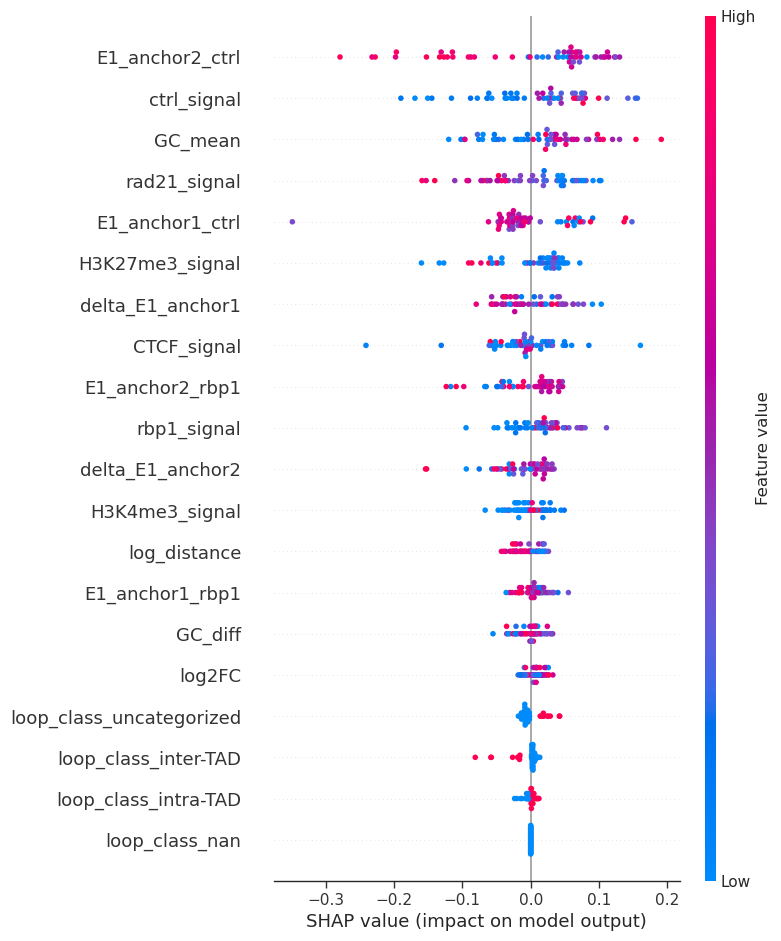

In [16]:
# model explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

In [17]:
## catboost

Test MSE:  0.2272
Test RMSE: 0.4766
Test R²:   -0.0987

Top features:
 E1_anchor2_ctrl         27.065934
GC_mean                 17.106685
rad21_signal             8.148955
rbp1_signal              8.143507
delta_E1_anchor1         7.214852
ctrl_signal              5.238977
H3K27me3_signal          5.153347
E1_anchor1_rbp1          4.496165
loop_class_intra-TAD     4.374076
log2FC                   4.157183
delta_E1_anchor2         2.822915
log_distance             1.681785
E1_anchor2_rbp1          1.080501
E1_anchor1_ctrl          0.974732
CTCF_signal              0.855194
dtype: float64


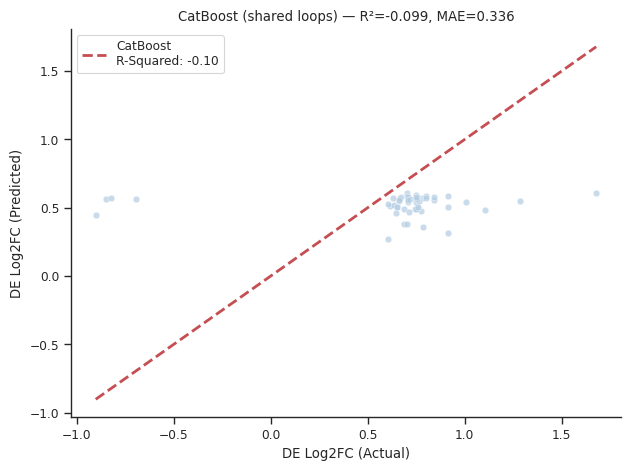

In [18]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# === Model ===
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=0
)

# CatBoost handles categorical vars directly, but if all features are numeric you can just fit
model.fit(X_train, y_train, eval_set=(X_test, y_test))

# === Predictions ===
y_pred = model.predict(X_test)

# === Metrics ===
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"Test MSE:  {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")

# === Feature importance ===
imp = model.get_feature_importance()
feat_imp = (
    pd.Series(imp, index=X_train.columns)
    .sort_values(ascending=False)
)
print("\nTop features:\n", feat_imp.head(15))

# === Actual vs Predicted Plot ===
r_squared = f"R-Squared: {r2:.2f}"
model_info = f"CatBoost\n{r_squared}"

ax = sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label=model_info)

ax.set_xlabel("DE Log2FC (Actual)")
ax.set_ylabel("DE Log2FC (Predicted)")
ax.set_title(f"CatBoost (shared loops) — R²={r2:.3f}, MAE={mae:.3f}")
ax.legend()
plt.tight_layout()
plt.show()

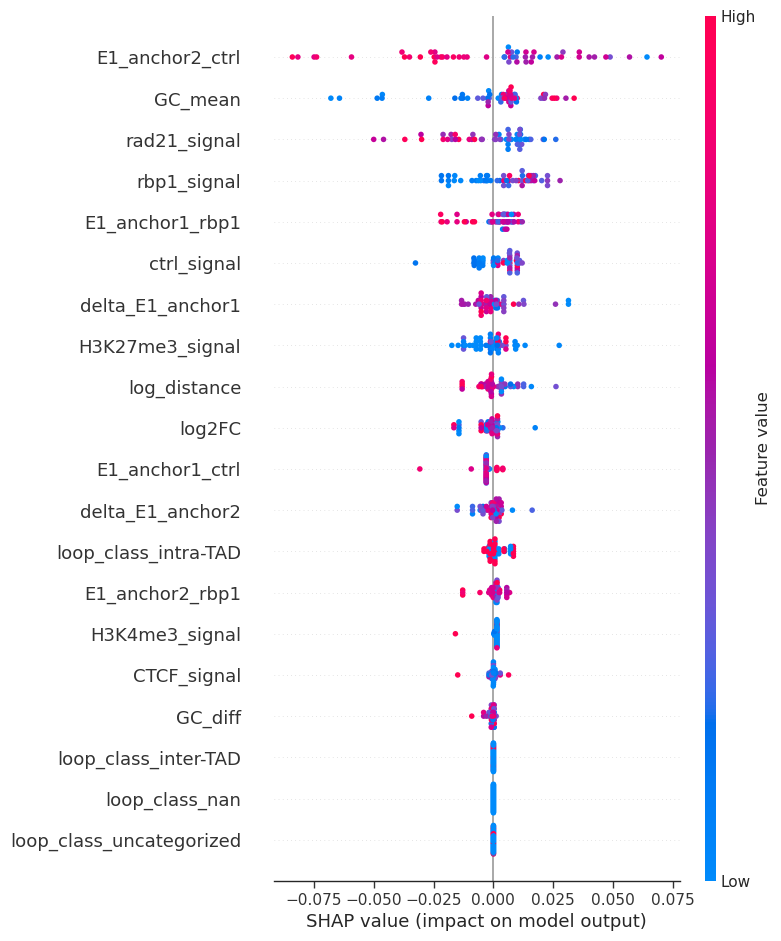

In [19]:
# model explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

```
x=y_test → the true values of gene_log2fc (differential expression log2 fold change) for the held-out test set.

y=y_pred → the model’s predictions of gene_log2fc for the same test set.

at the level of “shared loops” in your trimmed dataset, the features you’ve provided don’t carry predictive signal for expression changes.
```

In [20]:
## No subsetting # Using all

LOW, HIGH = -5, 5

# No subset
df = merged

feat_cols = [
    'ctrl_signal','rbp1_signal',
    'CTCF_signal','H3K27me3_signal','H3K4me3_signal','rad21_signal',
    'GC_mean','GC_diff',
    'E1_anchor1_ctrl','E1_anchor1_rbp1','E1_anchor2_ctrl','E1_anchor2_rbp1',
    'delta_E1_anchor1','delta_E1_anchor2','log2FC'
]
if 'distance' in df.columns:
    df['log_distance'] = np.log1p(df['distance'])
    feat_cols.append('log_distance') # taking log of the distance
    ## These are the features fed to the model

# build feature frame
X = df[feat_cols].copy()

# one‑hot encode loop_class ## categorical
if 'loop_class' in df.columns:
    X = pd.concat([X, pd.get_dummies(df['loop_class'], prefix='loop_class', dummy_na=True)], axis=1)

# target
y = df['gene_log2fc'].copy() # target is the Differential expression log fold change

# outlier trim on both target and log2FC predictor ## Usually outliers are problematic
mask = y.between(LOW, HIGH) & X['log2FC'].between(LOW, HIGH)
X = X.loc[mask]
y = y.loc[mask]

# clean NaNs/Infs and keep aligned indices ## xgboost doesn't handle NaNs
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]  # align

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model
model = XGBRegressor(
    n_estimators=1000, max_depth=7, eta=0.1,
    subsample=0.7, colsample_bytree=0.8,
    reg_lambda=1.0, random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

# metrics
y_pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # MAE
r2   = r2_score(y_test, y_pred)
print(f"Test MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f}") # Test R2

cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
cv_r2  = cross_val_score(model, X, y, scoring='r2', cv=cv, n_jobs=-1)
print(f"CV R²: {cv_r2.mean():.3f} ({cv_r2.std():.3f})") # Cross val. R2
from xgboost import plot_importance
plot_importance(model, max_num_features=10)
plt.tight_layout()
plt.show()
# Fit model
model.fit(X_train, y_train)

# Predict and evaluate R²
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R² on test set: {r2:.4f}")
# === plot: actual vs predicted ===
r_squared = f"R-Squared: {r2:.2f}"
model_info = f"XGBoost\n{r_squared}"

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, s=12, alpha=0.7)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--', lw=2, label=model_info)
plt.xlabel("Actual gene_log2fc")
plt.ylabel("Predicted gene_log2fc")
plt.title(f"XGBoost (shared loops) — R²={r2:.3f}, MAE={mae:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

# Reuse X_train, X_test, y_train, y_test from the XGB cell

lgbm = LGBMRegressor(
    objective='regression',
    metric='rmse',
    boosting_type='gbdt',
    num_leaves=31,
    learning_rate=0.05,
    feature_fraction=0.9,
    n_estimators=2000,      # plenty of rounds; early_stopping will cut it
    random_state=42,
    n_jobs=-1
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_names=['valid'],
    callbacks=[early_stopping(stopping_rounds=100, verbose=False)]
)

# Predictions + metrics
y_pred = lgbm.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"Test RMSE: {rmse:.3f} | Test R²: {r2:.3f}")

# Feature importance (gain)
imp = pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop features:\n", imp.head(15))

# Actual vs Predicted plot
r_squared = f"R-Squared: {r2:.2f}"
model_info = f"LightGBM\n{r_squared}"

ax = sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
mn = min(y_test.min(), y_pred.min()); mx = max(y_test.max(), y_pred.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label=model_info)
ax.set_xlabel("Actual gene_log2fc")
ax.set_ylabel("Predicted gene_log2fc")
ax.set_title("LightGBM (shared loops, trimmed)")
ax.legend()
plt.tight_layout()
plt.show()

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# === Model ===
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=0
)

# CatBoost handles categorical vars directly, but if all features are numeric you can just fit
model.fit(X_train, y_train, eval_set=(X_test, y_test))

# === Predictions ===
y_pred = model.predict(X_test)

# === Metrics ===
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"Test MSE:  {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")

# === Feature importance ===
imp = model.get_feature_importance()
feat_imp = (
    pd.Series(imp, index=X_train.columns)
    .sort_values(ascending=False)
)
print("\nTop features:\n", feat_imp.head(15))

# === Actual vs Predicted Plot ===
r_squared = f"R-Squared: {r2:.2f}"
model_info = f"CatBoost\n{r_squared}"

ax = sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label=model_info)

ax.set_xlabel("DE Log2FC (Actual)")
ax.set_ylabel("DE Log2FC (Predicted)")
ax.set_title("CatBoost Regressor — Actual vs Predicted (shared loops)")
ax.legend()
plt.tight_layout()
plt.show()

# model explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)